# 🌳 GridSearchCV en Árboles de Decisión (Decision Trees)

## 📌 ¿Qué es GridSearchCV?

**GridSearchCV** es una técnica de **búsqueda exhaustiva de hiperparámetros** que permite encontrar automáticamente la **mejor combinación de parámetros** para un modelo de Machine Learning.

Funciona probando **todas las combinaciones posibles** de hiperparámetros definidos por el usuario y evaluándolas usando **validación cruzada (cross-validation)**.

En scikit-learn, `GridSearchCV` se utiliza para:
- Optimizar modelos
- Reducir el error
- Evitar overfitting
- Mejorar la capacidad de generalización

---

## 🎯 ¿Para qué sirve GridSearchCV en Árboles de Decisión?

En los **Árboles de Decisión**, el rendimiento del modelo depende fuertemente de sus **hiperparámetros**.  
Si no se ajustan correctamente, el árbol puede:

❌ Sobreajustarse (árbol muy profundo)  
❌ Subajustarse (árbol demasiado simple)

GridSearchCV permite encontrar el **equilibrio óptimo** entre complejidad y desempeño.

---

## ⚙️ Principales hiperparámetros que optimiza en Decision Trees

| Hiperparámetro | Descripción |
|----------------|------------|
| `max_depth` | Profundidad máxima del árbol |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en una hoja |
| `criterion` | Métrica para medir la calidad de la división (`gini`, `entropy`, `log_loss`) |
| `max_features` | Número de variables consideradas en cada división |

---

## 🔍 ¿Cómo funciona GridSearchCV?

1️⃣ Se define un **grid de hiperparámetros**  
2️⃣ Se entrena el modelo con **todas las combinaciones posibles**  
3️⃣ Cada combinación se evalúa usando **validación cruzada**  
4️⃣ Se selecciona la combinación con el **mejor score promedio**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_df = sns.load_dataset('titanic')
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
columns_to_drop = ['fare','embarked','class','who','adult_male','deck','embark_town','alive','alone']
titanic_df.drop(columns_to_drop,axis='columns',inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
888,0,3,female,NaN,1,2
889,1,1,male,26.0,0,0


In [4]:
titanic_df.dropna(inplace=True)

In [5]:
titanic_df = pd.get_dummies(titanic_df,columns=['sex'],drop_first=True)
titanic_df.head()

,survived,pclass,age,sibsp,parch,sex_male
0,0,3,22.0,1,0,True
1,1,1,38.0,1,0,False
2,1,3,26.0,0,0,False
3,1,1,35.0,1,0,False
4,0,3,35.0,0,0,True


In [6]:
titanic_df['sex_male'] = titanic_df['sex_male'].astype(int)
titanic_df.rename(columns = {'sex_male':'sex'},inplace=True)
titanic_df.head(10)

,survived,pclass,age,sibsp,parch,sex
0,0,3,22.0,1,0,1
1,1,1,38.0,1,0,0
2,1,3,26.0,0,0,0
3,1,1,35.0,1,0,0
4,0,3,35.0,0,0,1
6,0,1,54.0,0,0,1
7,0,3,2.0,3,1,1
8,1,3,27.0,0,2,0
9,1,2,14.0,1,0,0
10,1,3,4.0,1,1,0


# DIVISION DE DATASET EN ENTRENAMIENTO Y PRUEBA

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = titanic_df.drop('survived',axis=1)
y = titanic_df['survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=00000)

# EVALUANDO LA MEJOR COMBINACIÓN DE PARAMETROS CON GRIDSEARCHCV

In [8]:
from sklearn.model_selection import GridSearchCV

## DEFINIR VARIOS HYERPARAMETROS

In [9]:
param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}

## CREAMOS EL MODELO

In [10]:
clf = DecisionTreeClassifier(random_state=42)

## APLICAMOS GRIDSEARCHCV

In [11]:
grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)
print(f'Mejor combinación de parámetros: {grid_search.best_params_}')

Mejor combinación de parámetros: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}


# ENTRENAMIENTO DE MODELO CON MEJORES PARAMETROS

In [12]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Exactitud del modelo: {accuracy}')

Exactitud del modelo: 0.8041958041958042


# VERIFICAMOS LAS VARIABLES MAS IMPORTANTES

In [13]:
importances = best_model.feature_importances_
importances

array([0.27356075, 0.15794155, 0.10860427, 0.00564495, 0.45424848])

In [14]:
columns = X.columns
columns

Index(['pclass', 'age', 'sibsp', 'parch', 'sex'], dtype='object')

/tmp/ipykernel_4911/158995257.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns,y=importances,palette='bright',saturation= 2.0,edgecolor='black',linewidth=2)


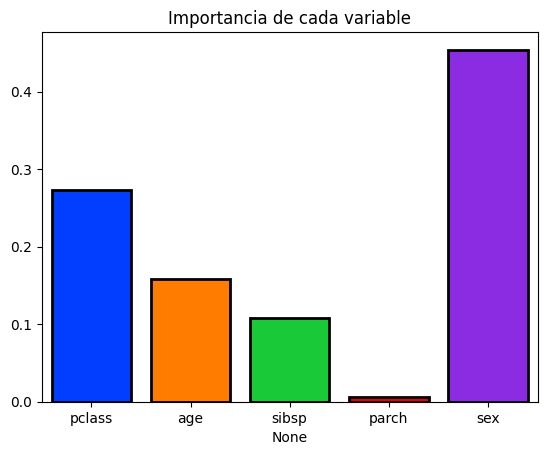

In [15]:
sns.barplot(x=columns,y=importances,palette='bright',saturation= 2.0,edgecolor='black',linewidth=2)
plt.title('Importancia de cada variable')
plt.show()